In [91]:
# Install Required Libraries

pip install pandas numpy matplotlib scikit-learn seaborn pyodbc streamlit

SyntaxError: invalid syntax (2549438266.py, line 3)

In [ ]:
pip install --upgrade pandas numpy matplotlib scikit-learn seaborn pyodbc streamlit

In [ ]:
pip install pyodbc sqlalchemy

In [ ]:
# Packages

import pandas as pd
import numpy as np
import matplotlib as plt
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import datetime
import statsmodels.formula.api as smf
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder
import streamlit
import pyodbc
import pickle

In [ ]:
# Create SQL Connection

conn = pyodbc.connect(
    'DRIVER={SQL Server};'
    'SERVER=SHASWATHE\SQLEXPRESS;'
    'DATABASE=LoanRiskAnalysis;'
    'Trusted_Connection=yes;'
)

In [ ]:
# Importing the dataset from the SQL

internal_df = pd.read_sql(
    "SELECT * FROM INTERNAL_BANK_DATA",
    conn
)

In [92]:
internal_df.head()

,PROSPECTID,Total_TL,Tot_Closed_TL,Tot_Active_TL,Total_TL_opened_L6M,Tot_TL_closed_L6M,pct_tl_open_L6M,pct_tl_closed_L6M,pct_active_tl,pct_closed_tl,...,CC_TL,Consumer_TL,Gold_TL,Home_TL,PL_TL,Secured_TL,Unsecured_TL,Other_TL,Age_Oldest_TL,Age_Newest_TL
0,1,5,4,1,0,0,0.000,0.0,0.200,0.800,...,0,0,1,0,4,1,4,0,72,18
1,2,1,0,1,0,0,0.000,0.0,1.000,0.000,...,0,1,0,0,0,0,1,0,7,7
2,3,8,0,8,1,0,0.125,0.0,1.000,0.000,...,0,6,1,0,0,2,6,0,47,2
3,4,1,0,1,1,0,1.000,0.0,1.000,0.000,...,0,0,0,0,0,0,1,1,5,5
4,5,3,2,1,0,0,0.000,0.0,0.333,0.667,...,0,0,0,0,0,3,0,2,131,32


In [93]:
external_df = pd.read_sql(
    "SELECT * FROM EXTERNAL_CIBIL_DATA",
    conn
)

C:\Users\SHASWATHE\AppData\Local\Temp\ipykernel_22556\493457230.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  external_df = pd.read_sql(


In [94]:
external_df.head()

,PROSPECTID,time_since_recent_payment,time_since_first_deliquency,time_since_recent_deliquency,num_times_delinquent,max_delinquency_level,max_recent_level_of_deliq,num_deliq_6mts,num_deliq_12mts,num_deliq_6_12mts,...,pct_CC_enq_L6m_of_L12m,pct_PL_enq_L6m_of_ever,pct_CC_enq_L6m_of_ever,max_unsec_exposure_inPct,HL_Flag,GL_Flag,last_prod_enq2,first_prod_enq2,Credit_Score,Approved_Flag
0,1,549,35,15,11,29,29,0,0,0,...,0.0,0.0,0.0,13.333000,1,0,PL,PL,696,2.0
1,2,47,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.860000,0,0,ConsumerLoan,ConsumerLoan,685,2.0
2,3,302,11,3,9,25,25,1,9,8,...,0.0,0.0,0.0,5741.666992,1,0,ConsumerLoan,others,693,2.0
3,4,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,9.900000,0,0,others,others,673,2.0
4,5,583,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.000000,0,0,AL,AL,753,1.0


In [95]:
# Checking the Dataset Shape

internal_df.shape

(51336, 26)

In [96]:
external_df.shape

(51336, 62)

In [97]:
# Checking the Missing Values

internal_df.isnull().sum()

PROSPECTID              0
Total_TL                0
Tot_Closed_TL           0
Tot_Active_TL           0
Total_TL_opened_L6M     0
Tot_TL_closed_L6M       0
pct_tl_open_L6M         0
pct_tl_closed_L6M       0
pct_active_tl           0
pct_closed_tl           0
Total_TL_opened_L12M    0
Tot_TL_closed_L12M      0
pct_tl_open_L12M        0
pct_tl_closed_L12M      0
Tot_Missed_Pmnt         0
Auto_TL                 0
CC_TL                   0
Consumer_TL             0
Gold_TL                 0
Home_TL                 0
PL_TL                   0
Secured_TL              0
Unsecured_TL            0
Other_TL                0
Age_Oldest_TL           0
Age_Newest_TL           0
dtype: int64

In [98]:
external_df.isnull().sum()

PROSPECTID                      0
time_since_recent_payment       0
time_since_first_deliquency     0
time_since_recent_deliquency    0
num_times_delinquent            0
                               ..
GL_Flag                         0
last_prod_enq2                  0
first_prod_enq2                 0
Credit_Score                    0
Approved_Flag                   0
Length: 62, dtype: int64

In [99]:
# Merge Both Dataset

df = pd.merge(internal_df, external_df, on = "PROSPECTID", how = "inner")

In [100]:
# Check Combined Dataset

df.head()

,PROSPECTID,Total_TL,Tot_Closed_TL,Tot_Active_TL,Total_TL_opened_L6M,Tot_TL_closed_L6M,pct_tl_open_L6M,pct_tl_closed_L6M,pct_active_tl,pct_closed_tl,...,pct_CC_enq_L6m_of_L12m,pct_PL_enq_L6m_of_ever,pct_CC_enq_L6m_of_ever,max_unsec_exposure_inPct,HL_Flag,GL_Flag,last_prod_enq2,first_prod_enq2,Credit_Score,Approved_Flag
0,1,5,4,1,0,0,0.000,0.0,0.200,0.800,...,0.0,0.0,0.0,13.333000,1,0,PL,PL,696,2.0
1,2,1,0,1,0,0,0.000,0.0,1.000,0.000,...,0.0,0.0,0.0,0.860000,0,0,ConsumerLoan,ConsumerLoan,685,2.0
2,3,8,0,8,1,0,0.125,0.0,1.000,0.000,...,0.0,0.0,0.0,5741.666992,1,0,ConsumerLoan,others,693,2.0
3,4,1,0,1,1,0,1.000,0.0,1.000,0.000,...,0.0,0.0,0.0,9.900000,0,0,others,others,673,2.0
4,5,3,2,1,0,0,0.000,0.0,0.333,0.667,...,0.0,0.0,0.0,0.000000,0,0,AL,AL,753,1.0


In [101]:
df.shape

(51336, 87)

In [102]:
# Replace the Invalid Values

df.replace(-99999, np.nan, inplace=True)

In [103]:
# Dataset Information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51336 entries, 0 to 51335
Data columns (total 87 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   PROSPECTID                    51336 non-null  int64  
 1   Total_TL                      51336 non-null  int64  
 2   Tot_Closed_TL                 51336 non-null  int64  
 3   Tot_Active_TL                 51336 non-null  int64  
 4   Total_TL_opened_L6M           51336 non-null  int64  
 5   Tot_TL_closed_L6M             51336 non-null  int64  
 6   pct_tl_open_L6M               51336 non-null  float64
 7   pct_tl_closed_L6M             51336 non-null  float64
 8   pct_active_tl                 51336 non-null  float64
 9   pct_closed_tl                 51336 non-null  float64
 10  Total_TL_opened_L12M          51336 non-null  int64  
 11  Tot_TL_closed_L12M            51336 non-null  int64  
 12  pct_tl_open_L12M              51336 non-null  float64
 13  p

In [104]:
#Checking the Statical Summary

df.describe()

,PROSPECTID,Total_TL,Tot_Closed_TL,Tot_Active_TL,Total_TL_opened_L6M,Tot_TL_closed_L6M,pct_tl_open_L6M,pct_tl_closed_L6M,pct_active_tl,pct_closed_tl,...,PL_Flag,pct_PL_enq_L6m_of_L12m,pct_CC_enq_L6m_of_L12m,pct_PL_enq_L6m_of_ever,pct_CC_enq_L6m_of_ever,max_unsec_exposure_inPct,HL_Flag,GL_Flag,Credit_Score,Approved_Flag
count,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000,...,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000
mean,25668.500000,4.858598,2.770415,2.088184,0.736754,0.428919,0.184574,0.089095,0.577542,0.422458,...,0.167874,0.190414,0.065182,0.170492,0.056302,21.207487,0.271116,0.052887,679.859222,2.261279
std,14819.571046,7.177116,5.941680,2.290774,1.296717,0.989972,0.297414,0.205635,0.379867,0.379867,...,0.373758,0.376218,0.235706,0.350209,0.213506,1110.299825,0.444540,0.223810,20.502764,0.805146
min,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,469.000000,1.000000
25%,12834.750000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.250000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,669.000000,2.000000
50%,25668.500000,2.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.556000,0.444000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.333000,0.000000,0.000000,680.000000,2.000000
75%,38502.250000,5.000000,3.000000,3.000000,1.000000,1.000000,0.308000,0.053000,1.000000,0.750000,...,0.000000,0.000000,0.000000,0.000000,0.000000,2.164250,1.000000,0.000000,691.000000,3.000000
max,51336.000000,235.000000,216.000000,47.000000,27.000000,19.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,173800.000000,1.000000,1.000000,811.000000,4.000000


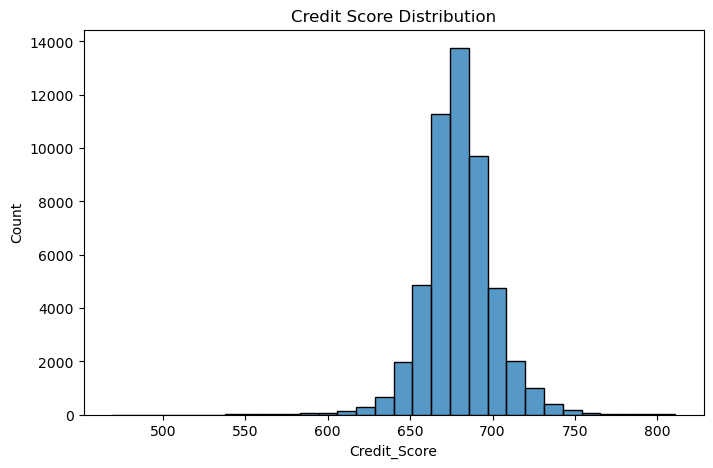

In [105]:
# First Visualization

plt.figure(figsize = (8,5))
sns.histplot(df['Credit_Score'],bins = 30)
plt.title("Credit Score Distribution")
plt.xlabel("Credit_Score")
plt.ylabel("Count")
plt.show()

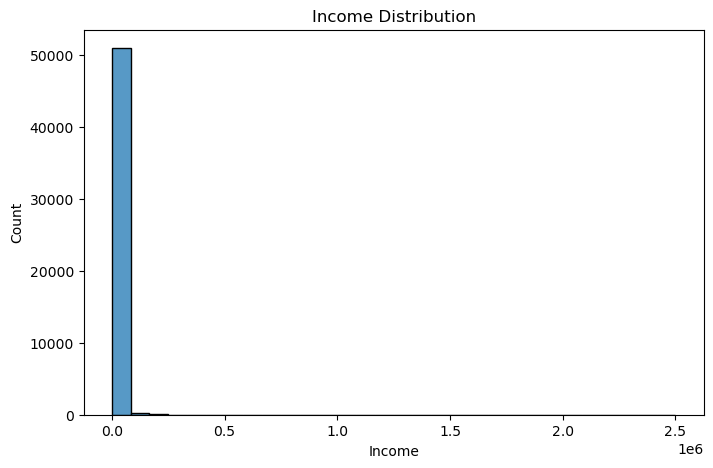

In [106]:
# Income Distribution

plt.figure(figsize = (8,5))
sns.histplot(df['NETMONTHLYINCOME'],bins = 30)
plt.title("Income Distribution")
plt.xlabel("Income")
plt.ylabel("Count")
plt.show()

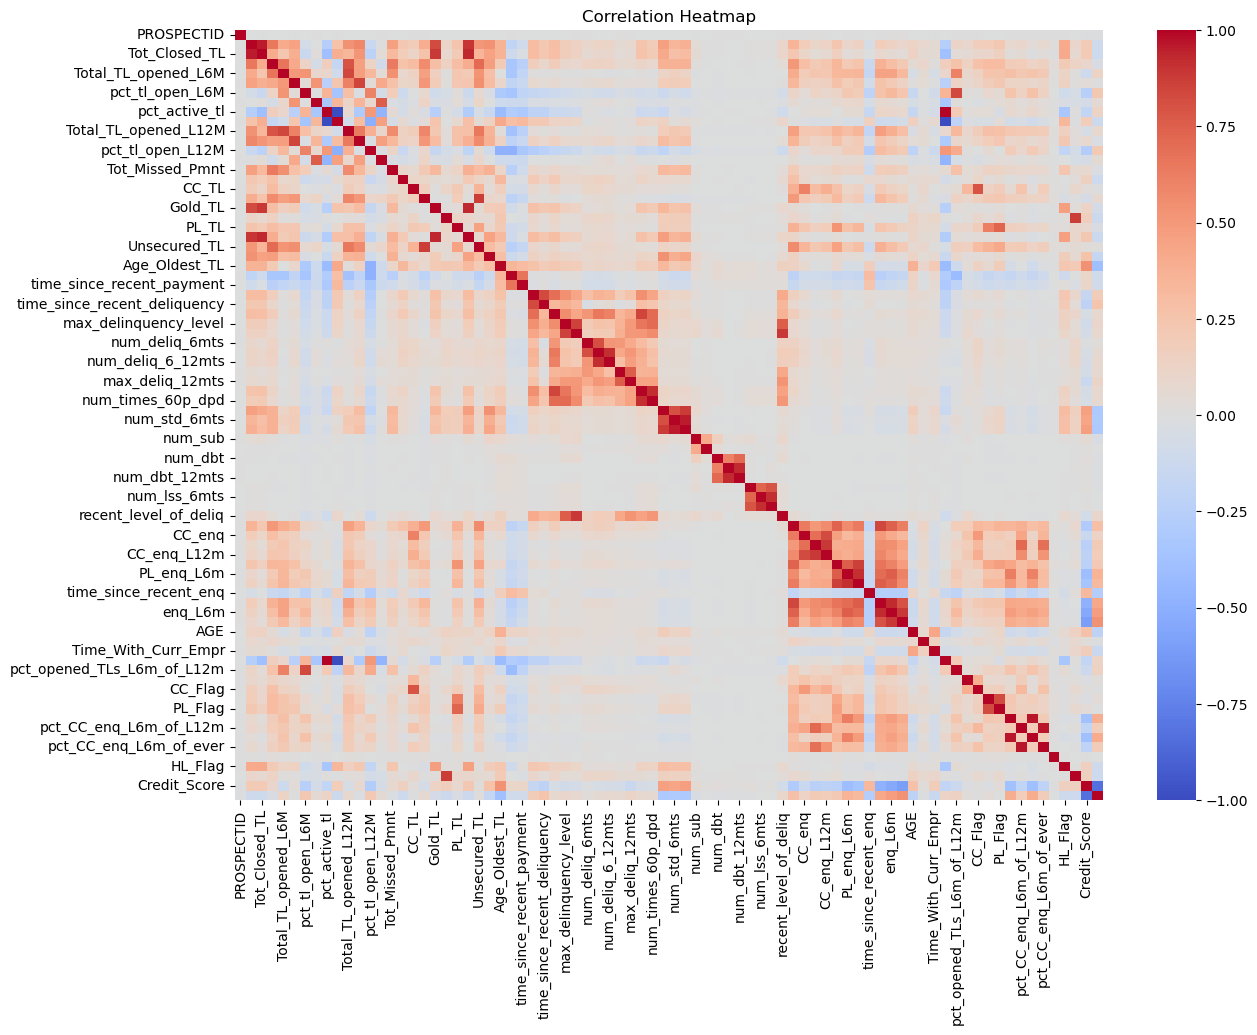

In [107]:
# Corelation Heatmap

plt.figure(figsize = (14,10))
sns.heatmap(df.corr(numeric_only = True), cmap = 'coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [108]:
# Create Risk Categories

def risk_category(Score):
    if Score >= 750:
        return "Low_Risk"
    elif Score >= 650:
        return "Medium_Risk"
    else:
        return "High_Risk"

In [109]:
df['Risk_Category'] = df['Credit_Score'].apply(risk_category)

In [110]:
df[['Credit_Score','Risk_Category']].head(10)

,Credit_Score,Risk_Category
0,696,Medium_Risk
1,685,Medium_Risk
2,693,Medium_Risk
3,673,Medium_Risk
4,753,Low_Risk
5,668,Medium_Risk
6,703,Medium_Risk
7,676,Medium_Risk
8,658,Medium_Risk
9,705,Medium_Risk


In [111]:
# Handle Missing Values

df.fillna(df.median(numeric_only=True), inplace=True)

In [112]:
# Convert Categorical Variables

from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()

In [113]:
df['GENDER'] = encoder.fit_transform(df['GENDER'])
df['MARITALSTATUS'] = encoder.fit_transform(df['MARITALSTATUS'])
df['EDUCATION'] = encoder.fit_transform(df['EDUCATION'])
df['Risk_Category'] = encoder.fit_transform(df['Risk_Category'])

In [114]:
df[['GENDER', 'MARITALSTATUS', 'EDUCATION', 'Risk_Category']].head()

,GENDER,MARITALSTATUS,EDUCATION,Risk_Category
0,1,0,0,2
1,0,1,1,2
2,1,0,5,2
3,1,0,5,2
4,1,0,3,1


In [115]:
# Features and Target

y = df['Risk_Category']
X = df[[
    'Credit_Score',
    'NETMONTHLYINCOME',
    'num_times_delinquent',
    'tot_enq',
    'CC_utilization',
    'PL_utilization',
    'Tot_Missed_Pmnt'
]]

In [116]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [117]:
# Train Test Logistical_Regression

model = LogisticRegression()
model.fit(X_train, y_train)

C:\Users\SHASWATHE\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  loss = "log"


LogisticRegression()

In [118]:
# Predictions
y_pred = model.predict(X_test)

In [119]:
# Evalute Model

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.9411764705882353


In [120]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.50      0.09      0.16       572
           1       0.00      0.00      0.00        32
           2       0.95      0.99      0.97      9664

    accuracy                           0.94     10268
   macro avg       0.48      0.36      0.38     10268
weighted avg       0.92      0.94      0.92     10268



C:\Users\SHASWATHE\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  return fbeta_score(
C:\Users\SHASWATHE\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  return fbeta_score(
C:\Users\SHASWATHE\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  return fbeta_score(


In [121]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

NameError: name 'confusion_matrix' is not defined

In [ ]:
# Feature Importance
importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
})

print(importance)

In [ ]:
# Create Prediction Systems

sample = [[700, 45000, 2, 3, 30, 20, 1]]

prediction = model.predict(sample)

print(prediction)

In [ ]:
# Save the Model it will create a new folder in the home and then only it is able to use streamlit app

pickle.dump(model, open('loan_risk_model.pkl', 'wb'))